# Text-Segmentierung Pakete

Segmentierung unter Verwendung der Bibliotheken pymupdf4llm und docling.

**Voraussetzungen**

Environment: package

Die Erkennung der Grenzen wird für die über den Datensatz zur Verfügung gestellten rohen PDF-Dokumente durchgeführt. Der Abgleich der erkannten Grenzen erfolgt über die gelabelten Dokumente, dazu muss die Vorverarbeitung und Erstellung der Dataframes über das Notebook Preparation.ipynb ausgeführt werden.

**Versuchsaufbau**

Die Pakete pymupdf4llm und docling bieten Funktionen zur Umwandlung von PDF-Dokumenten in das Markdown-Format, welches im Ergebnis die benötigten Informationen zu den Grenzen in Form von Markierungen der Überschriften-Hierachie liefert. Durchgeführt wird die Umwandlung auf Basis typografischer Merkmale der Text-Elemente eines Dokuments wie der Schrift-Art, Größe und Gewicht sowie deren Position und Anwendung heuristischer Regeln. Zur Verbesserung der Ergebnisse werden zusätzlich KI-gestützte Layout-Analysemodelle verwendet, mit deren Hilfe eine Klassifizierung der Elemente durchgeführt wird.

Die PDF-Dokumente werden jeweils durch die beiden Pakete verarbeitet und aus den resultierenden Markdown-Dateien die Informationen zu den erkannten Grenzen über die Markierungen der Überschriften extrahiert.

Wie für die Klassifikationsmodelle wird die Erkennung der Segmentgrenzen als binäres Klassifikationsproblem behandelt und zur Darstellung der Ergebnisse die Confusion-Matrix genutzt. Einziger Unterschied ist, dass durch die Pakete direkt keine Informationen über die richtig Negativ erkannten (TN) Blöcke zurüchgeliefert wird, sodass die Accuracy-Metrik nicht berechnet werden kann.

## Setup

### Pakete laden

In [1]:
# tesseract Umgebungsvariable
%env TESSDATA_PREFIX=/opt/tesseract/tessdata
#!set

import config

import os
import time
import json

import regex as re

import numpy as np
import pandas as pd

import pyarrow as pa
import pyarrow.parquet as pq

import pymupdf4llm
from pymupdf4llm.ocr import tesseract_api

#from docling.datamodel.base_models import InputFormat
#from docling.datamodel.pipeline_options import (
#    TesseractOcrOptions,
#    PdfPipelineOptions,
#)
#from docling.document_converter import DocumentConverter, PdfFormatOption

from docling.datamodel.base_models import InputFormat
from docling.document_converter import DocumentConverter, PdfFormatOption

# docling vllm
from docling.datamodel.pipeline_options import VlmPipelineOptions, AnyUrl, PdfPipelineOptions
from docling.pipeline.vlm_pipeline import VlmPipeline
from docling.datamodel.settings import settings
from docling.datamodel import vlm_model_specs

#docling gpu
from docling.datamodel.accelerator_options import AcceleratorDevice, AcceleratorOptions
from docling.datamodel.pipeline_options import ThreadedPdfPipelineOptions

from util.datasetprocessor import DatasetProcessor
from util.pdfprocessor import PDFProcessor
from util.px import PX
from util.helper import Helper

env: TESSDATA_PREFIX=/opt/tesseract/tessdata


### Variablen+Funktionen

In [2]:
# Klassen-Label
labels = ['positive', 'negative']

Funktion zur Erstellung der Confusion-Matrix aus Ergebnissen der Erkennung

In [3]:
def create_confusion_matrix(package, path, pdf_urls):
    cm = [[0, 0], [0, 0]]
    
    # Über URLs von PDF-Dokumenten iterieren
    #for doc_id in pdf_urls.index:
    for idx_doc in range(pdf_urls.shape[0]):
        doc_id = pdf_urls.iloc[idx_doc].name
        #doc_id = pdf_urls_clean_select.iloc[idx_doc].name
        print(doc_id)

        # Überschriften/Grenzen aus Vorverarbeiteten Dataframes extrahieren

        # PDF-Dokument laden
        df_doc_processed = pq.read_table(f'{config.dataset["path"]}pdfs_df_process/{doc_id}.parquet').to_pandas()
        
        # Einträge, für welche kein Embedding-Vektor vorhanden ist entfernen
        df_doc_processed = df_doc_processed.drop(df_doc_processed.loc[df_doc_processed['embedding'].isna()].index)

        # letzten Block ausschließen
        df_doc_processed = df_doc_processed.iloc[:-1]

        # Grenzen selektieren
        df_doc_processed_boundary = df_doc_processed.loc[df_doc_processed['boundary'] == True, 'text'].str.replace(r'[^\w\s]', '', regex=True).str.lower()#.str.replace(r'(^[A-Z]\.)\s([0-9]+)', r'\1\2', regex=True)

        # Dokument Markdown-Datei laden 
        try:
            file = open(f'{path}markdown/{package}/{doc_id}.txt', 'r')
            doc = file.read()
            file.close()
        except Exception as e:
            print(f"Exception occurred: {e}")

        # Erkannte Überschriften aus Markdown extrahieren
        
        # Text nach \n unterteilen und in Dataframe einlesen
        df_md = pd.DataFrame.from_dict({'text': doc.split('\n')}).convert_dtypes()

        # Zeilen aus Dataframe über regulären Ausdruck wählen, welche Markdown-Headings enthalten (r'^#+\s')
        df_md_headings = df_md.loc[df_md['text'].str.contains(r'^#+\s', regex=True), 'text'].str.replace(r'^#+\s', '', regex=True).str.replace(r'[^\w\s]', '', regex=True).str.strip(' *_').str.lower().reset_index(drop=True)#.str.replace(r'(^[A-Z]\.)\s([0-9]+)', r'\1\2', regex=True)

        # Confusion-Matrix aus Ergebnissen bilden
        cm = Helper.confusion_matrix(cm, df_doc_processed_boundary, df_md_headings)

    return cm

Funktion zur Umwandlung der Dokument mit den Pakete pymupdf4llm und docling in Markdown

In [4]:
def process_documents(package, path, pdf_urls, reset = False):
    time_stats = [[], []]

    # Konfiguration docling
    if package == 'docling':
        #OCR deaktivieren
        pdf_options = PdfPipelineOptions(do_ocr=False)
        
        #converter = DocumentConverter()
        
        converter = DocumentConverter(
            format_options={
                InputFormat.PDF: PdfFormatOption(pipeline_options=pdf_options)
            }
        )
    
    # Über URLs von PDF-Dokumenten iterieren
    #for doc_id in pdf_urls.index:
    for idx_doc in range(pdf_urls.shape[0]):
        doc_id = pdf_urls.iloc[idx_doc].name
        #doc_id = pdf_urls_clean_select.iloc[idx_doc].name
        print(doc_id)
    
        # Prüfen, ob Dokument bereits verarbeitet wurde und Datei mit Ergebnis vorhanden ist
        filename = f'{path}markdown/{package}/{doc_id}.txt'
    
        # wenn Datei bereits vorhanden laden
        if os.path.isfile(filename) and reset == False:
            try:
                file = open(filename, 'r')
                doc = file.read()
                file.close()
            except Exception as e:
                print(f"Exception occurred: {e}")
        else:
    
            time_stats[0].append(time.time())

            # PDF-Dokument mit pymupdf4llm in Markdown umwandeln
            if package == 'pymupdf4llm':
                doc = pymupdf4llm.to_markdown(f'{path}pdfs/{doc_id}.pdf', use_ocr=False)#, ocr_function=tesseract_api.exec_ocr, force_ocr=True, language="eng"
                
                # Seiten als chunks einlesen
                #doc = pymupdf4llm.to_markdown(f'{path}pdfs/{doc_id}.pdf', page_chunks=True)
                
                # Kopf-/Fußzeilen ausschließen
                #doc = pymupdf4llm.to_markdown(f'{path}pdfs/{doc_id}.pdf', header=False, footer=False)
                # funktioniert nicht
                # Bsp.: 
                # 2411.00713v1
                # JONAS BLESSING, MICHAEL KUPPER, AND ALESSANDRO SGARABOTTOLO
                # RISK-BASED PRICES
                
            # PDF-Dokument mit docling in Markdown umwandeln
            elif package == 'docling':
                result = converter.convert(f'{path}pdfs/{doc_id}.pdf')
                doc = result.document.export_to_markdown(image_mode="placeholder", include_annotations=True)
        
            time_stats[1].append(time.time())
        
            # Markdown als txt-Datei speichern
            try:
                file = open(filename, 'w')
                file.write(doc)
                file.close()
            except Exception as e:
                print(f"Exception occurred: {e}")
        
            #for chunk in doc:
            #    print(chunk['text'])
        
            #print(json.loads(doc).keys())
            #print(doc[0]['text'])

    return time_stats

### Daten laden

In [5]:
# Answers
answers = pd.read_json(f'{config.dataset["path"]}answers.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: "answer"})
# Queries
queries = pd.read_json(f'{config.dataset["path"]}queries.json', orient='index', dtype_backend='numpy_nullable')
# Relations
qrels = pd.read_json(f'{config.dataset["path"]}qrels.json', orient='index', dtype_backend='numpy_nullable')

# PDF URLs
#pdf_urls = pd.read_json(f'{config.dataset["path"]}pdf_urls.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: "pdf_urls"})

pdf_urls_clean = pd.read_json(f'{config.dataset["path"]}pdf_urls_clean.json', orient='index', dtype_backend='numpy_nullable')#.rename(columns={0: "pdf_urls"})
pdf_urls = pdf_urls_clean.loc[pdf_urls_clean.values]

### Fragen selektieren

Fragen mit Quelle "Text" und "Text-Tabelle" und mindestens acht Wörtern in der Referenz-Antwort (Fragen mit kurzen Antworten wie "yes" ausschließen) für Ausführung selektieren

In [6]:
# Fragen und Antworten über Index joinen
queries_answers = queries.merge(answers, how='inner', left_index=True, right_index=True)

# Anzahl Wörter der Fragen 
queries_answers['answer_replace'] = queries_answers['answer'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True)
queries_answers['answer_word_count'] = queries_answers['answer_replace'].str.split(' ').str.len()

# Fragen mit source=text|text-table und answer_word_count>=8
queries_text_text_table = queries_answers.loc[((queries_answers['source'] == 'text') | (queries_answers['source'] == 'text-table')) & (queries_answers['answer_word_count'] >= 8)]

# 1/4 der Fragen selektieren
queries_text_text_table = queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42)

Anzahl bereinigter Dokumente, auf welche sich die gewählten Fragen beziehen.

In [5]:
# Anzahl Fragen source=text|text-table und answer_word_count>=8

# 1/1
#print(queries_text_text_table.shape[0])
#1719

# 1/4
#print(queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42).shape[0])
#430

In [6]:
# Anzahl Dokumente, auf die sich die gewählten Fragen beziehen

# 1/1
#print(qrels.loc[queries_text_text_table.index]['doc_id'].unique().shape[0])
#385

# 1/4
#print(qrels.loc[queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42).index]['doc_id'].unique().shape[0])
#266

In [7]:
# Anzahl gewählter Dokumente, welche aus Datensatz entfernt wurden

# 1/1
#qrels_select = qrels.loc[queries_text_text_table.index]
#print(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)]['doc_id'].unique().shape[0])
# 37

# 1/4
#qrels_select = qrels.loc[queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42).index]
#print(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)]['doc_id'].unique().shape[0])
# 21

In [8]:
# Beireinigte Dokumente, auf welche sich die gewählten Fragen beziehen

# 1/1
#qrels_select = qrels.loc[queries_text_text_table.index]
#qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)
#print(pdf_urls.loc[qrels_select['doc_id'].unique()].shape[0])
#348

# 1/4
#qrels_select = qrels.loc[queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42).index]
#qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)
#print(pdf_urls.loc[qrels_select['doc_id'].unique()].shape[0])
#245

Für die Erkennung werden alle bereinigten Dokumente verwendet, auf welche sich die gewählten Fragen beziehen.

Die gewählten 430 Fragen beziehen sich auf 266 Dokumente. 21 der Dokumente wurden im Zuge der Bereinigung ausgeschlossen und für die Erkennung werden die verbleibenden 245 Dokumente verwendet.

In [7]:
# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)

pdf_urls_select = pdf_urls.loc[qrels_select['doc_id'].unique()]

## Ausführung

### Umwandlung in Markdown mit pymupdf4llm

https://pymupdf.readthedocs.io/en/latest/pymupdf4llm/

**pymupdf-layout**  
https://pypi.org/project/pymupdf-layout/

**ocr-plugins**  
https://pymupdf.readthedocs.io/en/latest/pymupdf4llm/ocr-plugins.html

Fehler Bsp.: 2408.08383v2

#### Convert

Umwandlung der Dokumente in Markdown mit pymupdf4llm

In [8]:
#pymupdf4llm.use_layout(False)

time_stats = process_documents('pymupdf4llm', config.dataset['path'], pdf_urls_select, reset=False)

2406.06650v2
2412.05495v6
2412.15929v3
2410.19654v2
2409.12776v2
2409.14246v2
2410.16076v3
2401.14085v2
2410.24112v2
2408.04814v3
2412.04468v2
2404.17509v2
2407.11894v2
2412.15322v2
2403.03363v6
2408.06103v2
2408.16245v3
2407.11761v3
2411.11402v4
2410.08287v3
2408.13702v3
2401.07294v4
2405.13422v2
2406.17374v2
2412.13042v2
2409.11339v2
2411.14884v3
2405.05734v3
2411.03309v2
2410.23841v2
2405.13879v3
2411.10728v3
2409.18681v6
2405.20415v3
2408.14507v2
2408.17106v2
2411.17395v2
2410.07168v2
2409.04843v2
2411.10511v4
2408.06050v2
2411.07483v2
2403.05373v2
2408.06274v3
2403.04635v2
2412.14566v2
2407.02507v2
2412.21038v2
2404.18137v2
2409.06994v3
2411.16245v2
2405.07102v4
2405.01155v3
2406.16586v3
2409.13333v2
2412.06947v3
2412.03227v2
2410.15316v3
2402.04429v3
2411.02796v2
2409.16644v2
2410.11034v2
2407.17674v2
2410.17011v3
2411.19887v2
2412.15239v2
2412.15448v2
2410.20812v3
2409.09862v3
2406.05923v2
2410.14997v2
2409.02772v2
2401.06326v4
2406.15888v2
2401.03305v2
2402.02272v2
2406.02319v2

#### Time stats

Ausgabe der benötigten Zeiten für Verarbeitung einer Stichprobe von 100 Dokumenten

In [9]:
time_stats = np.array(time_stats)
time_stats_diff = time_stats[1] - time_stats[0]

print(f'sum {time_stats_diff.sum()}')
print(f'mean {time_stats_diff.mean()}')
print(f'min {time_stats_diff.min()}')
print(f'max {time_stats_diff.max()}')
print(f'std {time_stats_diff.std()}')

#sum 3390.994168996811
#mean 13.840792526517596
#min 0.6235239505767822
#max 1699.411866426468
#std 110.47789724291462

sum 3390.994168996811
mean 13.840792526517596
min 0.6235239505767822
max 1699.411866426468
std 110.47789724291462


#### Confusion-Matrix

Erstellung und Ausgabe der Confusion-Matrix für Ergebnisse

In [10]:
cm = create_confusion_matrix('pymupdf4llm', config.dataset['path'], pdf_urls_select)

2406.06650v2
2412.05495v6
2412.15929v3
2410.19654v2
2409.12776v2
2409.14246v2
2410.16076v3
2401.14085v2
2410.24112v2
2408.04814v3
2412.04468v2
2404.17509v2
2407.11894v2
2412.15322v2
2403.03363v6
2408.06103v2
2408.16245v3
2407.11761v3
2411.11402v4
2410.08287v3
2408.13702v3
2401.07294v4
2405.13422v2
2406.17374v2
2412.13042v2
2409.11339v2
2411.14884v3
2405.05734v3
2411.03309v2
2410.23841v2
2405.13879v3
2411.10728v3
2409.18681v6
2405.20415v3
2408.14507v2
2408.17106v2
2411.17395v2
2410.07168v2
2409.04843v2
2411.10511v4
2408.06050v2
2411.07483v2
2403.05373v2
2408.06274v3
2403.04635v2
2412.14566v2
2407.02507v2
2412.21038v2
2404.18137v2
2409.06994v3
2411.16245v2
2405.07102v4
2405.01155v3
2406.16586v3
2409.13333v2
2412.06947v3
2412.03227v2
2410.15316v3
2402.04429v3
2411.02796v2
2409.16644v2
2410.11034v2
2407.17674v2
2410.17011v3
2411.19887v2
2412.15239v2
2412.15448v2
2410.20812v3
2409.09862v3
2406.05923v2
2410.14997v2
2409.02772v2
2401.06326v4
2406.15888v2
2401.03305v2
2402.02272v2
2406.02319v2

#### Metriken

Berechnung der Metriken Recall und Precision für Messung der Genauigkeit der Erkennung

In [11]:
print('confusion matrix')
print(np.array(cm))

print(f'recall {Helper.confusion_matrix_tpr(cm)}')
print(f'precision {Helper.confusion_matrix_ppv(cm)}')
#print(f'f1 score {Helper.confusion_matrix_f1_score(cm)}')

#confusion matrix
#[[4574  766]
# [1759    0]]
#recall 0.8565543071161049
#precision 0.7222485393968103

#[5340, 6333]

confusion matrix
[[4574  766]
 [1759    0]]
recall 0.8565543071161049
precision 0.7222485393968103


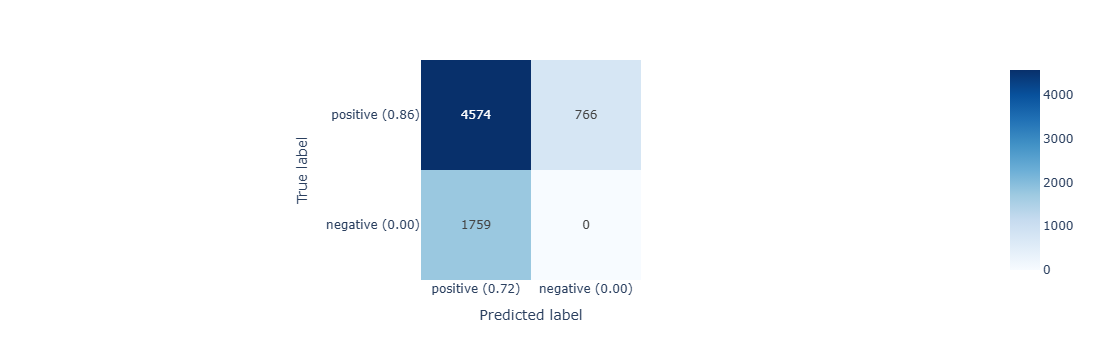

In [12]:
PX.displayConfusionMatrix(np.array(cm), width=450, xaxes={'labels': labels, 'title': 'Predicted label'}, yaxes={'labels': labels, 'title': 'True label'})

Durch das Paket pymupdf4llm wurden 4574  der insgesamt 5340 Grenzen aus den 245 verwendeten Dokumenten richtig erkannt und ein Recall von ca. 0.857 erreicht. Von den insgesamt 6333 durch das Paket erkannten Grenzen stellen 1759 keine Grenze dar, was einer Precision von 0.722 entspricht. Wenn dass Paket eine Grenze erkennt, ist die Erkennung nur in ca. 72,2% der Fälle richtig und damit nicht sehr genau.

Folgende Einschränkung gibt es zu beachten. Die durch das Paket erkannten Grenzen wurden mit den bereinigten Dokumenten verglichen. Es ist möglich, dass durch das Paket Grenzen erkannt wurden, die auch tatsächlich eine Grenze darstellen aber in den bereinigten Dokumenten nicht vorhanden sind.

Die Verarbeitung eines Dokuments hat durchschnittlich 14 Sekunden gedauert.

### Umwandlung in Markdown mit docling

https://docling-project.github.io/docling

**GPU-Support**  
https://docling-project.github.io/docling/getting_started/rtx  
https://docling-project.github.io/docling/usage/gpu/

**OCR engines**  
https://docling-project.github.io/docling/getting_started/installation/#ocr-engines

#### Convert

Umwandlung der Dokumente in Markdown mit pymupdf4llm

In [15]:
time_stats = process_documents('docling', config.dataset['path'], pdf_urls_select, reset=False)

2406.06650v2


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

W0901 20:48:06.636000 4463 torch/_dynamo/variables/tensor.py:1759] [0/0] Graph break from `Tensor.item()`, consider setting:
W0901 20:48:06.636000 4463 torch/_dynamo/variables/tensor.py:1759] [0/0]     torch._dynamo.config.capture_scalar_outputs = True
W0901 20:48:06.636000 4463 torch/_dynamo/variables/tensor.py:1759] [0/0] or:
W0901 20:48:06.636000 4463 torch/_dynamo/variables/tensor.py:1759] [0/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0901 20:48:06.636000 4463 torch/_dynamo/variables/tensor.py:1759] [0/0] to include these operations in the captured graph.
W0901 20:48:06.636000 4463 torch/_dynamo/variables/tensor.py:1759] [0/0] 
W0901 20:48:06.636000 4463 torch/_dynamo/variables/tensor.py:1759] [0/0] Graph break: from user code at:
W0901 20:48:06.636000 4463 torch/_dynamo/variables/tensor.py:1759] [0/0]   File "/home/chris/venv/package/lib/python3.11/site-packages/transformers/utils/generic.py", line 911, in wrapper
W0901 20:48:06.636000 4463 torch/_dynamo/variables/tensor.py:

2412.05495v6
2412.15929v3
2410.19654v2
2409.12776v2
2409.14246v2
2410.16076v3
2401.14085v2
2410.24112v2
2408.04814v3
2412.04468v2
2404.17509v2
2407.11894v2
2412.15322v2
2403.03363v6
2408.06103v2
2408.16245v3
2407.11761v3
2411.11402v4
2410.08287v3
2408.13702v3
2401.07294v4
2405.13422v2
2406.17374v2
2412.13042v2
2409.11339v2
2411.14884v3
2405.05734v3
2411.03309v2
2410.23841v2
2405.13879v3
2411.10728v3
2409.18681v6
2405.20415v3
2408.14507v2
2408.17106v2
2411.17395v2
2410.07168v2
2409.04843v2
2411.10511v4
2408.06050v2
2411.07483v2
2403.05373v2
2408.06274v3
2403.04635v2
2412.14566v2
2407.02507v2
2412.21038v2
2404.18137v2
2409.06994v3
2411.16245v2
2405.07102v4
2405.01155v3
2406.16586v3
2409.13333v2
2412.06947v3
2412.03227v2
2410.15316v3
2402.04429v3
2411.02796v2
2409.16644v2
2410.11034v2
2407.17674v2
2410.17011v3
2411.19887v2
2412.15239v2
2412.15448v2
2410.20812v3
2409.09862v3
2406.05923v2
2410.14997v2
2409.02772v2
2401.06326v4
2406.15888v2
2401.03305v2
2402.02272v2
2406.02319v2
2411.12860v4

In [ ]:
#W0810 13:01:14.379000 3971 torch/_dynamo/variables/tensor.py:1759] [0/0] Graph break from `Tensor.item()`, consider setting:
#W0810 13:01:14.379000 3971 torch/_dynamo/variables/tensor.py:1759] [0/0]     torch._dynamo.config.capture_scalar_outputs = True
#W0810 13:01:14.379000 3971 torch/_dynamo/variables/tensor.py:1759] [0/0] or:
#W0810 13:01:14.379000 3971 torch/_dynamo/variables/tensor.py:1759] [0/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
#W0810 13:01:14.379000 3971 torch/_dynamo/variables/tensor.py:1759] [0/0] to include these operations in the captured graph.

#### Time stats

Ausgabe der benötigten Zeiten für Verarbeitung einer Stichprobe von 100 Dokumenten

In [16]:
time_stats = np.array(time_stats)
time_stats_diff = time_stats[1] - time_stats[0]

print(f'sum {time_stats_diff.sum()}')
print(f'mean {time_stats_diff.mean()}')
print(f'min {time_stats_diff.min()}')
print(f'max {time_stats_diff.max()}')
print(f'std {time_stats_diff.std()}')

#sum 1179.397268295288
#mean 4.813866401205257
#min 0.5746138095855713
#max 82.4030225276947
#std 6.464243970346447

sum 1179.397268295288
mean 4.813866401205257
min 0.5746138095855713
max 82.4030225276947
std 6.464243970346447


#### Confusion-Matrix

Erstellung und Ausgabe der Confusion-Matrix für Ergebnisse

In [17]:
cm = create_confusion_matrix('docling', config.dataset['path'], pdf_urls_select)

2406.06650v2
2412.05495v6
2412.15929v3
2410.19654v2
2409.12776v2
2409.14246v2
2410.16076v3
2401.14085v2
2410.24112v2
2408.04814v3
2412.04468v2
2404.17509v2
2407.11894v2
2412.15322v2
2403.03363v6
2408.06103v2
2408.16245v3
2407.11761v3
2411.11402v4
2410.08287v3
2408.13702v3
2401.07294v4
2405.13422v2
2406.17374v2
2412.13042v2
2409.11339v2
2411.14884v3
2405.05734v3
2411.03309v2
2410.23841v2
2405.13879v3
2411.10728v3
2409.18681v6
2405.20415v3
2408.14507v2
2408.17106v2
2411.17395v2
2410.07168v2
2409.04843v2
2411.10511v4
2408.06050v2
2411.07483v2
2403.05373v2
2408.06274v3
2403.04635v2
2412.14566v2
2407.02507v2
2412.21038v2
2404.18137v2
2409.06994v3
2411.16245v2
2405.07102v4
2405.01155v3
2406.16586v3
2409.13333v2
2412.06947v3
2412.03227v2
2410.15316v3
2402.04429v3
2411.02796v2
2409.16644v2
2410.11034v2
2407.17674v2
2410.17011v3
2411.19887v2
2412.15239v2
2412.15448v2
2410.20812v3
2409.09862v3
2406.05923v2
2410.14997v2
2409.02772v2
2401.06326v4
2406.15888v2
2401.03305v2
2402.02272v2
2406.02319v2

#### Metriken

Berechnung der Metriken Recall und Precision für Messung der Genauigkeit der Erkennung

In [18]:
print('confusion matrix')
print(np.array(cm))
print(f'recall {Helper.confusion_matrix_tpr(cm)}')
print(f'precision {Helper.confusion_matrix_ppv(cm)}')
#print(f'f1 score {Helper.confusion_matrix_f1_score(cm)}')

#confusion matrix
#[[4778  563]
# [1877    0]]
#recall 0.8945890282718592
#precision 0.7179564237415477

#[5341, 6655]

confusion matrix
[[4778  563]
 [1877    0]]
recall 0.8945890282718592
precision 0.7179564237415477


Mit dem Paket docling wurden 4778 der Grenzen richtig erkannt, was einem Recall von ca. 0.895 entspricht. Insgesamt wurden 6655 Grenzen erkannt, von denen 1877 keine tatsächliche Grenze darstellen, woraus sich eine Precision von 0.718 ergibt.

Gegenüber dem Paket pymupdf4llm, mit welchem einen Recall von 0.857 erzielt wurde, werden die Grenzen durch das Paket docling etwas besser erkannt. Die Precision der Erkennung ist für beide Pakete annähernd gleich und ca. jede vierte erkannte Grenze stellt keine tatsächliche Grenze dar.

Die für die Verarbeitung eines Dokuments mit dem Paket benötigte durchschnittliche Zeit ist mit ca. 5 Sekunden deutlich geringer.

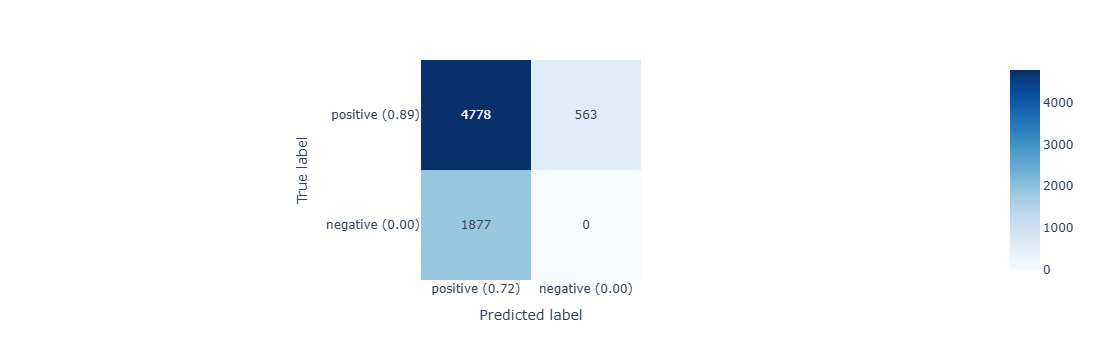

In [21]:
PX.displayConfusionMatrix(np.array(cm), width=450, xaxes={'labels': labels, 'title': 'Predicted label'}, yaxes={'labels': labels, 'title': 'True label'})

## Sample

Ausgabe der Ergebnisse der Umwandlung/Erkennung für einzelne Beispiel-Dokumente

In [ ]:
# Positiv-Beispiel

#https://arxiv.org/pdf/2406.06650v2
#https://arxiv.org/pdf/2412.05495v6

# Negativ-Beispiel

#https://arxiv.org/pdf/2401.14085v2
#https://arxiv.org/pdf/2410.24112v2
#https://arxiv.org/pdf/2410.08287v3

### Positiv-Beispiel

2406.06650v2
[[16, 0], [7, 0]]


/home/chris/dskim/Master-Thesis/work/util/px.py:164: RuntimeWarning: invalid value encountered in scalar divide
  ticktext=[f'{xaxes["labels"][i]} ({cm[i][i]/cm.sum(axis=0)[i]:.2f})' for i in range(len(xaxes['labels']))] if len(xaxes['labels']) == 2 else (xaxes['labels'] if ticktextlen == None else [f'{s[:30]}...' for s in xaxes['labels']]),


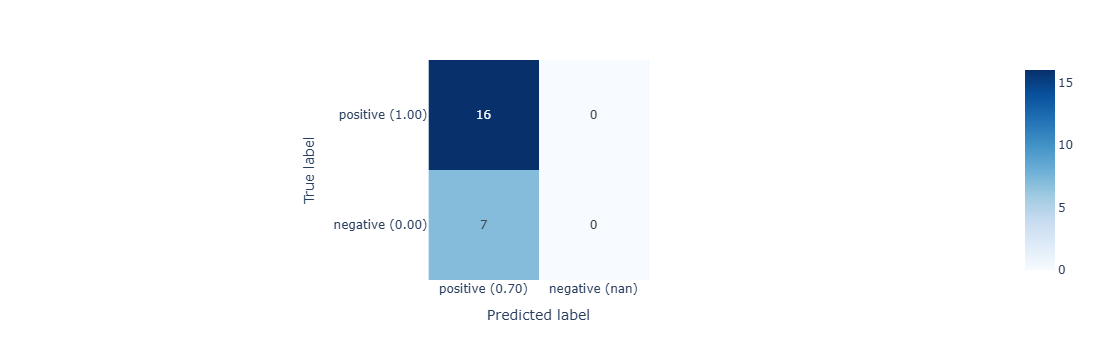

recall 1.0
precision 0.6956521739130435


In [15]:
# pymupdf4llm

cm = create_confusion_matrix('pymupdf4llm', config.dataset['path'], pdf_urls_select.loc[['2406.06650v2']])

print(cm)

PX.displayConfusionMatrix(np.array(cm), width=450, xaxes={'labels': labels, 'title': 'Predicted label'}, yaxes={'labels': labels, 'title': 'True label'})

print(f'recall {Helper.confusion_matrix_tpr(cm)}')
print(f'precision {Helper.confusion_matrix_ppv(cm)}')
#print(f'f1 score {Helper.confusion_matrix_f1_score(cm)}')

2406.06650v2
[[16, 0], [8, 0]]


/home/chris/dskim/Master-Thesis/work/util/px.py:164: RuntimeWarning: invalid value encountered in scalar divide
  ticktext=[f'{xaxes["labels"][i]} ({cm[i][i]/cm.sum(axis=0)[i]:.2f})' for i in range(len(xaxes['labels']))] if len(xaxes['labels']) == 2 else (xaxes['labels'] if ticktextlen == None else [f'{s[:30]}...' for s in xaxes['labels']]),


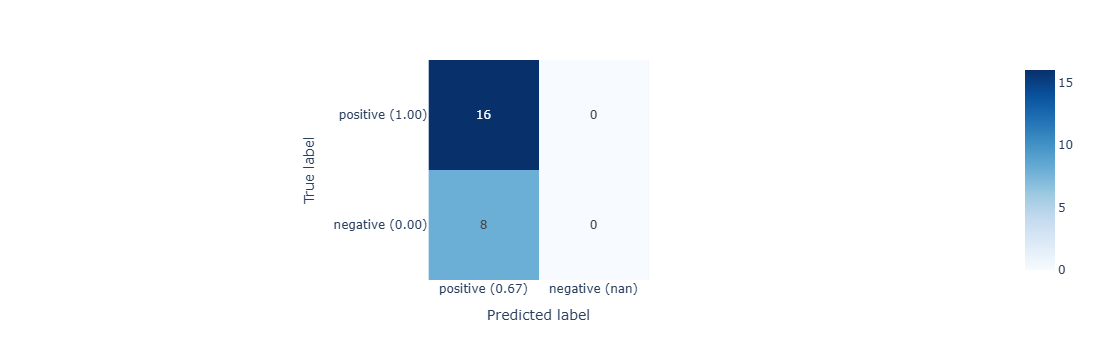

recall 1.0
precision 0.6666666666666666


In [24]:
# docling

cm = create_confusion_matrix('docling', config.dataset['path'], pdf_urls_select.loc[['2406.06650v2']])

print(cm)

PX.displayConfusionMatrix(np.array(cm), width=450, xaxes={'labels': labels, 'title': 'Predicted label'}, yaxes={'labels': labels, 'title': 'True label'})

print(f'recall {Helper.confusion_matrix_tpr(cm)}')
print(f'precision {Helper.confusion_matrix_ppv(cm)}')
#print(f'f1 score {Helper.confusion_matrix_f1_score(cm)}')

### Negativ-Beispiel

2410.08287v3
[[12, 9], [7, 0]]


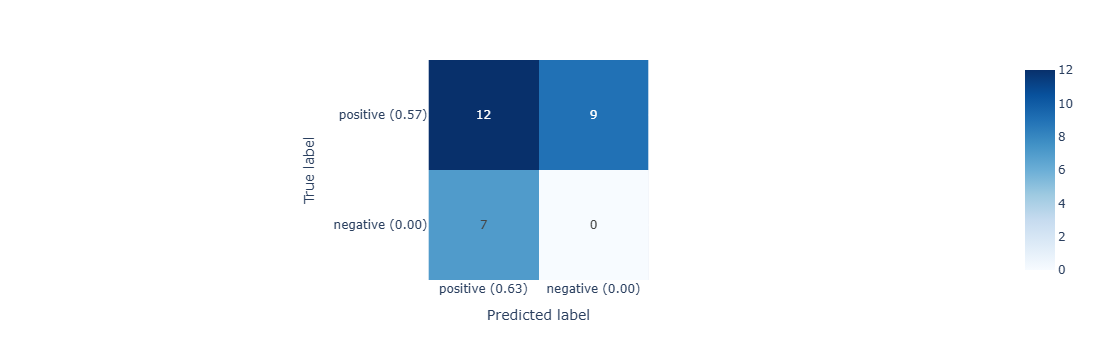

recall 0.5714285714285714
precision 0.631578947368421


In [17]:
# pymupdf4llm

cm = create_confusion_matrix('pymupdf4llm', config.dataset['path'], pdf_urls_select.loc[['2410.08287v3']])

print(cm)

PX.displayConfusionMatrix(np.array(cm), width=450, xaxes={'labels': labels, 'title': 'Predicted label'}, yaxes={'labels': labels, 'title': 'True label'})

print(f'recall {Helper.confusion_matrix_tpr(cm)}')
print(f'precision {Helper.confusion_matrix_ppv(cm)}')
#print(f'f1 score {Helper.confusion_matrix_f1_score(cm)}')

2410.08287v3
[[17, 4], [8, 0]]


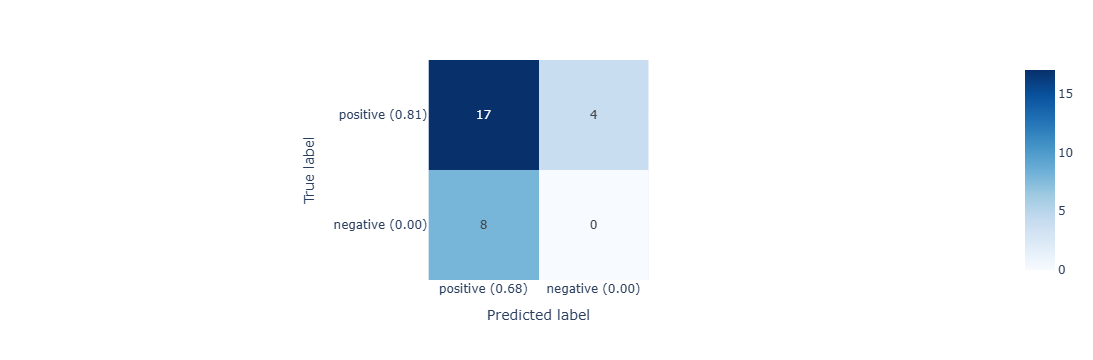

recall 0.8095238095238095
precision 0.68


In [25]:
# docling

cm = create_confusion_matrix('docling', config.dataset['path'], pdf_urls_select.loc[['2410.08287v3']])

print(cm)

PX.displayConfusionMatrix(np.array(cm), width=450, xaxes={'labels': labels, 'title': 'Predicted label'}, yaxes={'labels': labels, 'title': 'True label'})

print(f'recall {Helper.confusion_matrix_tpr(cm)}')
print(f'precision {Helper.confusion_matrix_ppv(cm)}')
#print(f'f1 score {Helper.confusion_matrix_f1_score(cm)}')

Nachteil der Verwendung typografischer Merkmale und heuristischer Regelen ist deren mangelnde Anpassungsfähigkeit. Sind die Merkmale vorhanden, funktioniert die Erkennung gut (z.B. Dokument 2406.06650v2), fehlen diese oder entsprechen nicht den Regeln, schlägt die Erkennung fehl (z.B. Dokument 2410.08287v3).

In [ ]:
"""# GPU Optionen
accelerator_options = AcceleratorOptions(
    device=AcceleratorDevice.CUDA,  # Use CUDA for NVIDIA GPUs
)

# Pipeline GPU Optionen
pipeline_options = ThreadedPdfPipelineOptions(
    ocr_batch_size=64,      # Increase batch size for GPU
    layout_batch_size=64,   # Increase batch size for GPU
    table_batch_size=4,
)

# Converter erstellen
converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            accelerator_options=accelerator_options,
            pipeline_options=pipeline_options,
        ),
    }
)

# Über URLs von PDF-Dokumenten iterieren
#for doc_id in pdf_urls_select.index:
for idx_doc in range(0,1):#pdf_urls_select.shape[0]
    doc_id = pdf_urls.iloc[idx_doc].name
    print(doc_id)

    time_start = time.time()

    result = converter.convert(f'{path}pdfs/{doc_id}.pdf')
    
    time_end = time.time()
    
    print(time_end - time_start)

    #md = result.document.export_to_markdown(image_mode="placeholder", include_annotations=True)
    #print(md)

    markdown_pages = []
    for page_no in range(1, len(result.document.pages) + 1):
        md = result.document.export_to_markdown(
            page_no=page_no,
            image_mode="placeholder",      # or "embedded" if you want images in the Markdown
            include_annotations=True       # include OCR/vision annotations if available
        )
        print(md)"""

In [ ]:
"""# Verwendung Modell ibm-granite/granite-docling-258M über VLLM
# Image-Text-to-Text

BATCH_SIZE = 16

# VLM options
#vlm_options = vlm_model_specs.GRANITEDOCLING_VLLM_API
#vlm_options.concurrency = BATCH_SIZE
#vlm_options.url = AnyUrl('http://192.168.5.133:8003/v1/chat/completions')

vlm_options = VlmPipelineOptions(
    enable_remote_services=True,
    vlm_options={
        "url": "('http://192.168.5.133:8003/v1/chat/completions",  # or any other compatible endpoint
        "params": {
            "model": "ibm-granite/granite-docling-258M",
            "max_tokens": 4096,
        },
        "concurrency": 64,  # default 1
        "prompt": "Convert this page to docling.",
        "timeout": 90,
    }
)

print(vlm_options)

# Set page batch size to match or exceed concurrency
settings.perf.page_batch_size = BATCH_SIZE

pipeline_options = VlmPipelineOptions(
    vlm_options=vlm_options
)

pipeline_options.enable_remote_services=True

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_cls=VlmPipeline,
            pipeline_options=pipeline_options,
        ),
    }
)

#converter = DocumentConverter()

# Über URLs von PDF-Dokumenten iterieren
#for doc_id in pdf_urls_select.index:
for idx_doc in range(0,1):#pdf_urls_select.shape[0]
    doc_id = pdf_urls.iloc[idx_doc].name
    print(doc_id)

    time_start = time.time()

    result = converter.convert(f'{path}pdfs/{doc_id}.pdf')
    
    time_end = time.time()
    
    print(time_end - time_start)

    md = result.document.export_to_markdown(image_mode="placeholder", include_annotations=True)
    print(md)

    #markdown_pages = []
    #for page_no in range(1, len(result.document.pages) + 1):
    #    md = result.document.export_to_markdown(
    #        page_no=page_no,
    #        image_mode="placeholder",      # or "embedded" if you want images in the Markdown
    #        include_annotations=True       # include OCR/vision annotations if available
    #    )
    #    print(md)"""